In [1]:
#April 22, 2026
#Charlotte Meyer
#Data Seminar
#This code uses cejst_logistic_regression.csv to create a logistic regression to predict which census tracts contain data centers.

In [2]:
#importing packages
import statsmodels.api
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report

In [3]:
#reading in the data 
cejst = pd.read_csv("cejst_logistic_regression.csv", index_col=0, low_memory=False)

#setting pandas columns so I can see all of them
pd.set_option('display.max_columns', None)

In [4]:
#possible predictor variables to consider
possible_predictors = ['perc_black', 'perc_native_american',
                      'perc_asian', 'perc_hawaiin_pacific', 'perc_mixed_race', 
                      'perc_white', 'perc_hispanic', 'perc_poverty', 'pm_air', 'perc_unemployment', 
                      'hazard_waste_prox', 'life_expectancy', 
                      'perc_elderly', 'perc_children', 'perc_disadvantaged', 
                      'population', 'loss_rate', 'flood_risk', 'energy_burden', 
                      'diesel_exposure', 'traffic_prox', 'travel_barriers', 
                      'housing_burden', 'house_value', 'pavement_cropland', 
                      'no_plumbing', 'superfund_prox', 'wastewater_discharge',
                      'asthma', 'diabetes', 'heart_disease', 'household_income_compared', 
                      'linguistic_isolation', 'no_hs_degree']

#actual predictor variables i will be using
predictors = ["perc_elderly", "loss_rate", "population", "perc_poverty", "superfund_prox"]
print(cejst[predictors].isnull().sum())

#notes on which predictors to involve:
#of all the race columns, perc_white had the strongest p-value and 2nd strongest coefficient (after perc_native_american)

#removing wastewater_discharge from predictors because it has 20,000 NA's
#over 5,000 NA's: life_expectancy, household_income_compared

#columns of interest:
#perc_poverty has a fairly strong coefficient
#perc_elderly has a lower p-value and stronger coefficeint
#loss_rate has a VERY strong coefficient (38) but high p-value
#population has a low p-value but the coefficent is almost 0
#energy_burden has a very low p-value
#no_plumbing has a fairly strong coefficient

#perc_poverty had highest multicollinearity

#i'm adding perc_poverty and superfund_prox because they both have strong coefficients

perc_elderly       861
loss_rate         1604
population          28
perc_poverty       158
superfund_prox     158
dtype: int64


In [5]:
#dropping NA's; code is from Claude


#dropping all rows with NaN in predictor columns
cejst = cejst.dropna(subset=predictors)

#verify they match
print(f"X shape: {cejst[predictors].shape}, y shape: {cejst['has_datacenter'].shape}")
#verify no na's
print(cejst[predictors].isnull().sum())

X shape: (72371, 5), y shape: (72371,)
perc_elderly      0
loss_rate         0
population        0
perc_poverty      0
superfund_prox    0
dtype: int64


In [6]:
#checking effect sizes on possible predictors

#fixed effects model
coefficients_model = statsmodels.formula.api.logit('has_datacenter ~ ' + ' + '.join(possible_predictors), 
    data=cejst, subset=None, drop_cols=None).fit(disp=False) 

coefficients_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         has_datacenter   No. Observations:                44016
Model:                          Logit   Df Residuals:                    43981
Method:                           MLE   Df Model:                           34
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.05005
Time:                        11:46:05   Log-Likelihood:                -1474.6
converged:                       True   LL-Null:                       -1552.3
Covariance Type:            nonrobust   LLR p-value:                 1.918e-17
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     3.0774      3.920      0.785      0.432      -4.606      10.761
perc_black                   -6.3756      3.499     -1.822      0.068     -13.233       0.482
perc_native_american         -6.1447      4.215     -1.458      0.145     -14.405       2.116
perc_asian                   -4.0519      3.568     -1.136      0.256     -11.045       2.941
perc_hawaiin_pacific         10.1824      6.690      1.522      0.128      -2.930      23.295
perc_mixed_race              -1.0776      3.371     -0.320      0.749      -7.684       5.529
perc_white                   -5.9390      3.502     -1.696      0.090     -12.803       0.925
perc_hispanic                -5.0992      3.366     -1.515      0.130     -11.697       1.498
perc_poverty                 -0.3546      1.112     -0.319      0.750      -2.534       1.825
pm_air                       -0.0471      0.048     -0.982      0.326      -0.141       0.047
perc_unemployment             0.0150      0.024      0.636      0.525      -0.031       0.061
hazard_waste_prox             0.0314      0.017      1.796      0.073      -0.003       0.066
life_expectancy               0.0043      0.024      0.174      0.862      -0.044       0.052
perc_elderly                 -2.4044      1.913     -1.257      0.209      -6.153       1.344
perc_children                -0.5139      1.990     -0.258      0.796      -4.415       3.387
perc_disadvantaged            0.0004      0.002      0.178      0.859      -0.004       0.005
population                -9.501e-05   3.38e-05     -2.808      0.005      -0.000   -2.87e-05
loss_rate                     6.4086     64.253      0.100      0.921    -119.525     132.343
flood_risk                   -0.0029      0.005     -0.626      0.532      -0.012       0.006
energy_burden                -0.3475      0.084     -4.140      0.000      -0.512      -0.183
diesel_exposure              -0.0607      0.406     -0.150      0.881      -0.856       0.734
traffic_prox                4.09e-07   3.75e-05      0.011      0.991   -7.31e-05    7.39e-05
travel_barriers              -0.0001      0.003     -0.046      0.964      -0.006       0.005
housing_burden               -0.0104      0.011     -0.960      0.337      -0.032       0.011
house_value               -1.415e-06   4.89e-07     -2.890      0.004   -2.37e-06   -4.55e-07
pavement_cropland             0.0033      0.003      1.049      0.294      -0.003       0.009
no_plumbing                   0.0674      0.241      0.279      0.780      -0.405       0.540
superfund_prox                0.0994      0.160      0.619      0.536      -0.215       0.414
wastewater_discharge         -0.0035      0.002     -1.488      0.137      -0.008       0.001
asthma                       -0.0030      0.004     -0.792      0.428      -0.011       0.004
diabetes                      0.0007      0.008      0.095      0.924      -0.014       0.016
heart_disease                -0.0046      0.0

In [7]:
#making a function that will split columns into bins for fixed effects

def split_into_bins(fixed_effect_column):

    #cut into 11 bins (arbitrary)
    #using cut, NOT qcut
    cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))
    
    #creating dummies
    dummies = pd.get_dummies(cejst[fixed_effect_column + "_bin"])
    
    #removing middle dummy
    dummies = dummies[[i for i in dummies.columns if i != 6]]
    
    #renaming dummies
    dummies.columns = [fixed_effect_column + "_" + str(i) for i in dummies.columns]

    #drop na
    dummies = dummies.dropna()
    
    #viewing bins
    return dummies

In [8]:
perc_white_dummies = split_into_bins("perc_white")
perc_white_dummies
cejst = pd.concat([cejst, perc_white_dummies], axis=1)

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_21523/3884202686.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))


In [9]:
no_plumbing_dummies = split_into_bins("no_plumbing")
no_plumbing_dummies
cejst = pd.concat([cejst, no_plumbing_dummies], axis=1)

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_21523/3884202686.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))


In [10]:
#energy burden is weird so we're not running the regular function
#this splits it into 3 bins instead


    #cut into 3 bins
    #using cut, NOT qcut
cejst["energy_burden_bin"] = pd.cut(cejst["energy_burden"], 3, labels=range(1,4))
    
    #creating dummies
dummies = pd.get_dummies(cejst["energy_burden_bin"])
    
    #removing middle dummy
dummies = dummies[[i for i in dummies.columns if i != 2]]
    
    #renaming dummies
dummies.columns = ["energy_burden_" + str(i) for i in dummies.columns]

    #drop na
dummies = dummies.dropna()
    
    #viewing bins
energy_burden_dummies = dummies 
cejst = pd.concat([cejst, energy_burden_dummies], axis=1)

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_21523/3313386171.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst["energy_burden_bin"] = pd.cut(cejst["energy_burden"], 3, labels=range(1,4))


In [11]:
cejst

,GEOID,County Name,State,perc_black,perc_native_american,perc_asian,perc_hawaiin_pacific,perc_mixed_race,perc_white,perc_hispanic,Percent other races,perc_children,Percent age 10 to 64,perc_elderly,Total threshold criteria exceeded,Total categories exceeded,Identified as disadvantaged without considering neighbors,Identified as disadvantaged based on neighbors and relaxed low income threshold only,Identified as disadvantaged due to tribal overlap,Identified as disadvantaged,perc_disadvantaged,Share of neighbors that are identified as disadvantaged,Identified as disadvantaged in v1.0,Identified as disadvantaged solely due to status in v1.0 (grandfathered),population,Interpolated number of off-campus students in poverty,Adjusted percent of individuals below 200% Federal Poverty Line (percentile),perc_poverty,Is low income?,Income data has been estimated based on geographic neighbor income,Greater than or equal to the 90th percentile for expected agriculture loss rate and is low income?,Expected agricultural loss rate (Natural Hazards Risk Index) (percentile),Expected agricultural loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected building loss rate and is low income?,Expected building loss rate (Natural Hazards Risk Index) (percentile),Expected building loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected population loss rate and is low income?,Expected population loss rate (Natural Hazards Risk Index) (percentile),loss_rate,Share of properties at risk of flood in 30 years (percentile),flood_risk,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years and is low income?,Share of properties at risk of fire in 30 years (percentile),Share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years and is low income?,Greater than or equal to the 90th percentile for energy burden and is low income?,Energy burden (percentile),energy_burden,Greater than or equal to the 90th percentile for PM2.5 exposure and is low income?,PM2.5 in the air (percentile),pm_air,Greater than or equal to the 90th percentile for diesel particulate matter and is low income?,Diesel particulate matter exposure (percentile),diesel_exposure,Greater than or equal to the 90th percentile for traffic proximity and is low income?,Traffic proximity and volume (percentile),traffic_prox,Greater than or equal to the 90th percentile for DOT transit barriers and is low income?,travel_barriers,Greater than or equal to the 90th percentile for housing burden and is low income?,Housing burden (percent) (percentile),housing_burden,"Greater than or equal to the 90th percentile for lead paint, the median house value is less than 90th percentile and is low income?",Percent pre-1960s housing (lead paint indicator) (percentile),Percent pre-1960s housing (lead paint indicator),Median value ($) of owner-occupied housing units (percentile),house_value,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent and is low income?,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent,Share of the tract's land area that is covered by impervious surface or cropland as a percent,pavement_cropland,Does the tract have at least 35 acres in it?,Tract experienced historic underinvestment and remains low income,Tract experienced historic underinvestment,no_plumbing,Share of homes with no kitchen or indoor plumbing (percent),Greater than or equal to the 90th percentile for proximity to hazardous waste facilities and is low income?,

In [12]:
#splitting train and test split
#this code is from Claude

#split the dataframe
train_df, test_df = train_test_split(cejst, test_size=0.25, random_state=29)

#how many data centers in test split?
pd.DataFrame(test_df["has_datacenter"]).value_counts()

has_datacenter
0                 18009
1                    84
Name: count, dtype: int64

In [13]:
#logistic regression model with fixed effects

#list of dummy dataframes
dummy_list = [perc_white_dummies, energy_burden_dummies, no_plumbing_dummies]

dummy_predictors = []
#making list of dummy columns
for new_dummy in dummy_list:
    #dummies that predict data center
    dummy_predictors.extend([i for i in new_dummy.columns if i != 'has_datacenter'])

print(dummy_predictors)

#combining regular predictor columns with dummy predictor columns
all_predictors = predictors + dummy_predictors
print(all_predictors)

#remove constant columns (aka columns that are exactly the same which makes code not work; had this with plumbing bins 2 and 3)
#code from Claude
constant_cols = [col for col in all_predictors if train_df[col].nunique() <= 1]
print(f"Removing {len(constant_cols)} constant columns: {constant_cols}")
all_predictors = [p for p in all_predictors if p not in constant_cols]

#fixed effects model
#fit on training data
#Claude says that  bfgs is more robust to collinearity. idk what maxiter=100 does.
my_fixed_effects_model = statsmodels.formula.api.logit('has_datacenter ~ ' + ' + '.join(all_predictors), 
    data=train_df, subset=None, drop_cols=None).fit(disp=False, method='bfgs', maxiter=100) 


# Evaluate on test data
test_predictions = my_fixed_effects_model.predict(test_df)

my_fixed_effects_model.summary()

['perc_white_1', 'perc_white_2', 'perc_white_3', 'perc_white_4', 'perc_white_5', 'perc_white_7', 'perc_white_8', 'perc_white_9', 'perc_white_10', 'perc_white_11', 'energy_burden_1', 'energy_burden_3', 'no_plumbing_1', 'no_plumbing_2', 'no_plumbing_3', 'no_plumbing_4', 'no_plumbing_5', 'no_plumbing_7', 'no_plumbing_8', 'no_plumbing_9', 'no_plumbing_10', 'no_plumbing_11']
['perc_elderly', 'loss_rate', 'population', 'perc_poverty', 'superfund_prox', 'perc_white_1', 'perc_white_2', 'perc_white_3', 'perc_white_4', 'perc_white_5', 'perc_white_7', 'perc_white_8', 'perc_white_9', 'perc_white_10', 'perc_white_11', 'energy_burden_1', 'energy_burden_3', 'no_plumbing_1', 'no_plumbing_2', 'no_plumbing_3', 'no_plumbing_4', 'no_plumbing_5', 'no_plumbing_7', 'no_plumbing_8', 'no_plumbing_9', 'no_plumbing_10', 'no_plumbing_11']
Removing 3 constant columns: ['energy_burden_3', 'no_plumbing_2', 'no_plumbing_3']


/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/stats

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         has_datacenter   No. Observations:                54278
Model:                          Logit   Df Residuals:                    54253
Method:                           MLE   Df Model:                           24
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.03725
Time:                        11:46:06   Log-Likelihood:                -1844.2
converged:                      False   LL-Null:                       -1915.5
Covariance Type:            nonrobust   LLR p-value:                 7.410e-19
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -4.8866      1.241     -3.939      0.000      -7.318      -2.455
perc_white_1[T.True]       -1.3959      0.427     -3.271      0.001      -2.232      -0.560
perc_white_2[T.True]       -0.7522      0.381     -1.973      0.049      -1.500      -0.005
perc_white_3[T.True]        0.4871      0.265      1.839      0.066      -0.032       1.006
perc_white_4[T.True]        0.2283      0.272      0.840      0.401      -0.304       0.761
perc_white_5[T.True]        0.4140      0.251      1.648      0.099      -0.078       0.906
perc_white_7[T.True]       -0.1170      0.258     -0.454      0.650      -0.622       0.388
perc_white_8[T.True]       -0.2029      0.249     -0.815      0.415      -0.691       0.285
perc_white_9[T.True]       -0.6481      0.264     -2.452      0.014      -1.166      -0.130
perc_white_10[T.True]      -0.3295      0.241     -1.370      0.171      -0.801       0.142
perc_white_11[T.True]      -0.9285      0.280     -3.318      0.001      -1.477      -0.380
energy_burden_1[T.True]     0.8660      1.264      0.685      0.493      -1.612       3.344
no_plumbing_1[T.True]       0.6447      0.276      2.333      0.020       0.103       1.186
no_plumbing_4[T.True]       0.4954      0.351      1.412      0.158      -0.192       1.183
no_plumbing_5[T.True]       0.7166      0.332      2.160      0.031       0.066       1.367
no_plumbing_7[T.True]       0.4143      0.358      1.156      0.248      -0.288       1.116
no_plumbing_8[T.True]       0.6070      0.345      1.758      0.079      -0.070       1.284
no_plumbing_9[T.True]       0.7138      0.339      2.107      0.035       0.050       1.378
no_plumbing_10[T.True]      0.3609      0.373      0.968      0.333      -0.370       1.092
no_plumbing_11[T.True]      0.7437      0.345      2.156      0.031       0.068       1.420
perc_elderly               -4.3300      0.995     -4.352      0.000      -6.280      -2.380
loss_rate                  -0.0023     49.051   -4.6e-05      1.000     -96.141      96.136
population              -5.031e-05   2.64e-05     -1.904      0.057      -0.000    1.48e-06
perc_poverty               -2.0089      0.389     -5.167      0.000      -2.771      -1.247
superfund_prox              0.1968      0.129      1.531      0.126      -0.055       0.449
===========================================================================================
"""

In [14]:
#looking at how good the model is
#the following chunks of code were originally in my scikitlearn logistic regression ipynb. 
#Because that is slightly different (splits into X and y, which this code does not), I asked Claude to adapt it for this model.

# calculating probability that each tract contains a data center
y_pred_proba = my_fixed_effects_model.predict(test_df)

# array of whether or not the model predicted that each tract would contain a data center
y_pred = (y_pred_proba > 0.005).astype(int)

# checking the data type of y_test
# a pandas series is a one-dimensional array with axis labels.
y_test = test_df['has_datacenter']
type(y_test)

pandas.Series

In [15]:
# results dataframe
# prob_0 is probability not a data center
# prob_1 is probability a data center
# also creating bins (below)
df_results = pd.DataFrame()
df_results['prediction'] = y_pred
df_results['prob_0'] = 1 - y_pred_proba
df_results['prob_1'] = y_pred_proba
df_results['label'] = y_test.to_list()
df_results['correct'] = df_results['prediction'] == df_results['label']
df_results['p1_bins'] = pd.qcut(df_results['prob_1'], q=30, labels=range(1, 31))
df_results.sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
10754,1,0.943287,0.056713,0,False,30
44412,1,0.960611,0.039389,0,False,30
8837,1,0.960919,0.039081,0,False,30
10640,1,0.963708,0.036292,0,False,30
68155,1,0.965741,0.034259,0,False,30
10660,1,0.965777,0.034223,0,False,30
44309,1,0.966364,0.033636,0,False,30
10820,1,0.966696,0.033304,0,False,30
10745,1,0.967025,0.032975,0,False,30
68154,1,0.967618,0.032382,0,False,30


In [16]:
# the tracts are sorted into 30 bins.
#they are sorted into these bins based on the probability that the tract contains a data center
#tracts in bin 1 are very unlikely to contain a data center
#tracts in bin 30 are very likely to contain a data center
#here we look at the percentage of tracts in each bin that were correctly identified by the model as either having or not having a data center

df_results.groupby('p1_bins')[['correct']].mean()

,correct
p1_bins,
1,1.000000
2,0.998342
3,1.000000
4,0.998342
5,0.998342
6,1.000000
7,1.000000
8,0.996683
9,0.998342


In [17]:
# looking at the tracts that DO contain data centers
df_results.loc[df_results['label'] == 1].sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
55267,1,0.975496,0.024504,1,True,30
38888,1,0.976673,0.023327,1,True,30
7356,1,0.979502,0.020498,1,True,30
68475,1,0.980731,0.019269,1,True,30
30456,1,0.981667,0.018333,1,True,30
29993,1,0.982224,0.017776,1,True,30
11187,1,0.982813,0.017187,1,True,30
10818,1,0.983357,0.016643,1,True,30
71692,1,0.985057,0.014943,1,True,29
22503,1,0.985102,0.014898,1,True,29


In [18]:
# looking at tracts with data centers that weren't predicted to have data centers
df_results.loc[(df_results['label'] == 1) & (df_results['correct'] == False)].sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
53498,0,0.995221,0.004779,1,False,16
68390,0,0.995293,0.004707,1,False,16
25771,0,0.995415,0.004585,1,False,15
27776,0,0.995501,0.004499,1,False,15
54937,0,0.995530,0.004470,1,False,15
66628,0,0.995540,0.004460,1,False,15
61585,0,0.995624,0.004376,1,False,15
42726,0,0.995896,0.004104,1,False,14
50762,0,0.996363,0.003637,1,False,12
67948,0,0.996841,0.003159,1,False,10


In [19]:
# how many does the model choose correctly?
df_results['correct'].value_counts()

correct
True     9796
False    8297
Name: count, dtype: int64

In [20]:
# new dataframe
# how much does each feature column affect the model?
# "score" for each feature column is the coefficient tells us how it is attributing to whether a tract is identified as a data center or not
# new cell here
df_coef = pd.DataFrame()
df_coef['feature'] = my_fixed_effects_model.params.index
df_coef['score'] = my_fixed_effects_model.params.values
df_coef

,feature,score
0,Intercept,-4.886637
1,perc_white_1[T.True],-1.395862
2,perc_white_2[T.True],-0.752152
3,perc_white_3[T.True],0.487122
4,perc_white_4[T.True],0.228317
5,perc_white_5[T.True],0.414025
6,perc_white_7[T.True],-0.117003
7,perc_white_8[T.True],-0.202944
8,perc_white_9[T.True],-0.648126
9,perc_white_10[T.True],-0.329467


In [21]:
# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}", float(df_results['correct'].sum()/df_results.shape[0] * 100))

accuracy: 0.54 54.14248604432653


In [22]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[9728, 8281],
       [  16,   68]])

In [23]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.54      0.70     18009
           1       0.01      0.81      0.02        84

    accuracy                           0.54     18093
   macro avg       0.50      0.67      0.36     18093
weighted avg       0.99      0.54      0.70     18093



In [24]:
# calculate recall
# recall: out of every tract that actually has data centers, how many are predicted to have data centers? (both classes combined)
recall = recall_score(y_test, y_pred)
f"Recall: {round(recall,2)}"

'Recall: 0.81'

In [32]:
# calculate precision
# precision: out of every tract predicted to have data centers, how many actually have data centers?

precision = precision_score(y_test, y_pred)
f"Precision: {round(precision,2)}"

'Precision: 0.01'

In [25]:
# calculate f1 score
# f1 score combines precision and recall into one metric
# f1 score = 2 _(p_r / p+r)
# f1 score is only high when both precision and recall are high
f1 = f1_score(y_test, y_pred)
f"f1 score: {round(f1,2)}"

'f1 score: 0.02'

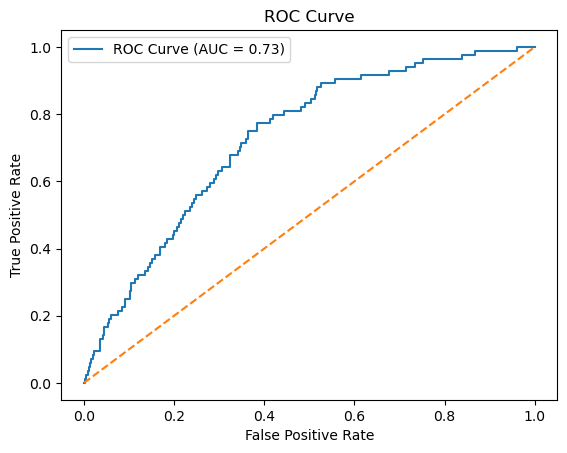

In [26]:
# ROC curve
# shows us the rate of true positive selections vs. false positive selections
# aka recall for class 1 vs. recall for class 0
# the sooner this line reaches 1.0, the better
# the closer this line is to the orange line, the worse -- orange is random selection
y_prob = y_pred_proba
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [28]:
#making X and y for the multicollinearity test
multicol_predictors = ["perc_elderly", "loss_rate", "population", "perc_poverty", "superfund_prox", "perc_white", "energy_burden", "no_plumbing"]
X = cejst[multicol_predictors]
y = cejst["has_datacenter"]

#dropping all rows with NaN in X columns
X = X.dropna()
#Keep y aligned with X
y = y.loc[X.index]  

# Verify they match
print(f"X shape: {X.shape}, y shape: {y.shape}")
#verify no na's
print(X.isnull().sum())

X shape: (72077, 8), y shape: (72077,)
perc_elderly      0
loss_rate         0
population        0
perc_poverty      0
superfund_prox    0
perc_white        0
energy_burden     0
no_plumbing       0
dtype: int64


In [29]:
#code adapted from https://www.statology.org/how-to-test-for-multicollinearity-with-statsmodels/
#testing for multicollinearity

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

          feature       VIF
0    perc_elderly  5.502219
1       loss_rate  1.115141
2      population  3.575767
3    perc_poverty  7.128949
4  superfund_prox  1.209395
5      perc_white  5.854006
6   energy_burden  6.836746
7     no_plumbing  4.154173


In [30]:
#diagnostics from Claude to figure out if i have class imbalance issue

# Check your class balance
print("Training set distribution:")
print(train_df['has_datacenter'].value_counts())
print(train_df['has_datacenter'].value_counts(normalize=True))

# Check what your model is predicting
print("\nPredictions distribution:")
print(df_results['prediction'].value_counts())
print(f"\nProbability range: {y_pred_proba.min():.4f} to {y_pred_proba.max():.4f}")

Training set distribution:
has_datacenter
0    53967
1      311
Name: count, dtype: int64
has_datacenter
0    0.99427
1    0.00573
Name: proportion, dtype: float64

Predictions distribution:
prediction
0    9744
1    8349
Name: count, dtype: int64

Probability range: 0.0000 to 0.0567


In [31]:
#figuring out which threshold to use for y_pred_proba
#code adapted from Claude

thresholds_to_try = [0.001, 0.005, 0.01, 0.05]
for threshold in thresholds_to_try:
    y_pred_temp = (y_pred_proba > threshold).astype(int)
    recall_temp = recall_score(y_test, y_pred_temp)
    precision_temp = precision_score(y_test, y_pred_temp)
    print(f"Threshold {threshold}: Recall={recall_temp:.2f}, Precision={precision_temp:.2f}")

Threshold 0.001: Recall=1.00, Precision=0.00
Threshold 0.005: Recall=0.81, Precision=0.01
Threshold 0.01: Recall=0.33, Precision=0.01
Threshold 0.05: Recall=0.00, Precision=0.00
